In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_excel(
    io.BytesIO(uploaded[file_name]),
    sheet_name="Sales_Dataset"
)

# Prepare data
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Dataset Shape:", df.shape)
display(df.head())

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset (1).xlsx
Dataset Shape: (1000, 12)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,980.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.360204,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,54.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.822597,2.838632,14179.402361,114100.051546


Total Sales: 139399439.65
Total Orders: 992
Total Customers: 947
Average Order Value: 139399.43965000001


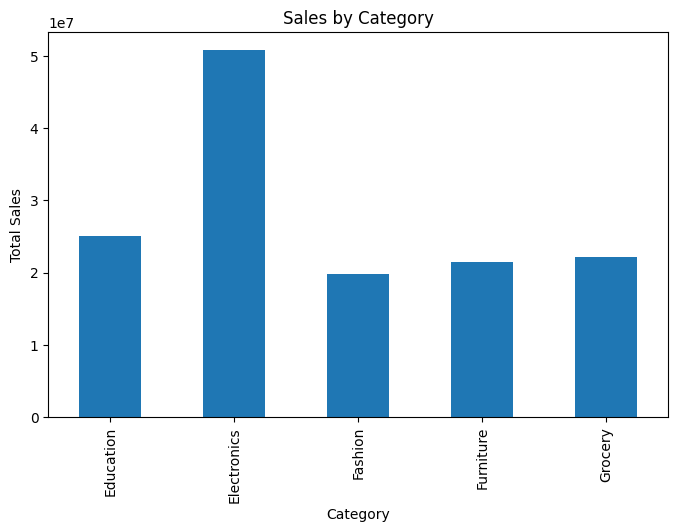

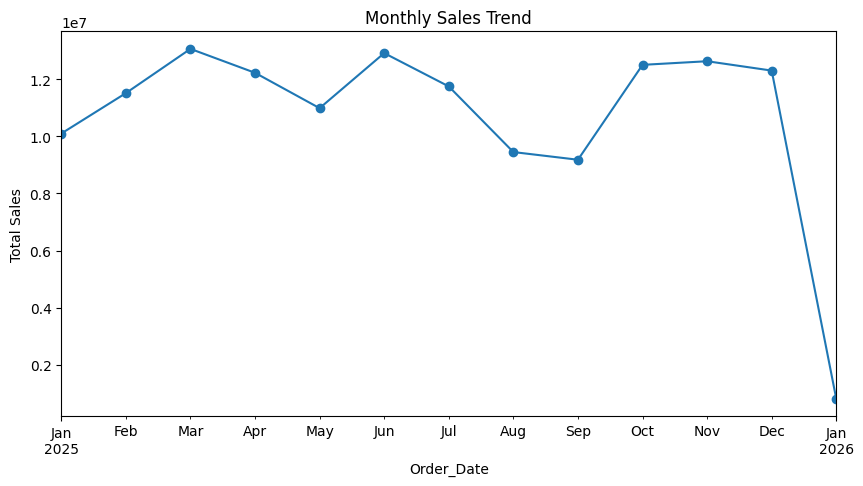

In [ ]:
import matplotlib.pyplot as plt

# Basic statistics
display(df.describe())

# Key metrics
print("Total Sales:", df["Total_Sales"].sum())
print("Total Orders:", df["Order_ID"].nunique())
print("Total Customers:", df["Customer_ID"].nunique())
print("Average Order Value:", df["Total_Sales"].mean())

# Sales by category
category_sales = df.groupby("Category")["Total_Sales"].sum()

# Sales by product
product_sales = df.groupby("Product")["Total_Sales"].sum()

# Monthly sales
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"]
    .sum()
)

# Visualizations
category_sales.plot(kind="bar", figsize=(8,5), title="Sales by Category")
plt.ylabel("Total Sales")
plt.show()

monthly_sales.plot(kind="line", marker="o", figsize=(10,5), title="Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

queries = {

"Q1 - Top 5 Products":
"""
SELECT Product, SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
LIMIT 5
""",

"Q2 - Sales by Category":
"""
SELECT Category, SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
""",

"Q3 - Sales by City":
"""
SELECT City, SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC
""",

"Q4 - Monthly Sales":
"""
SELECT strftime('%Y-%m', Order_Date) AS Month,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month
""",

"Q5 - Sales by Gender":
"""
SELECT Gender,
       SUM(Total_Sales) AS Total_Sales,
       AVG(Total_Sales) AS Average_Sales
FROM sales
GROUP BY Gender
ORDER BY Total_Sales DESC
""",

"Q6 - Sales by Age Group":
"""
SELECT
CASE
    WHEN Age <= 30 THEN '18-30'
    WHEN Age <= 45 THEN '31-45'
    WHEN Age <= 60 THEN '46-60'
    ELSE '60+'
END AS Age_Group,
SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Age_Group
ORDER BY Total_Sales DESC
""",

"Q7 - Top 10 Orders":
"""
SELECT Order_ID, Product, Category, Total_Sales
FROM sales
ORDER BY Total_Sales DESC
LIMIT 10
"""
}

for title, query in queries.items():
    print("\n" + "="*50)
    print(title)
    print("="*50)
    display(pd.read_sql_query(query, conn))


Q1 - Top 5 Products


,Product,Total_Sales
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48



Q2 - Sales by Category


,Category,Total_Sales
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79



Q3 - Sales by City


...

,Gender,Total_Sales,Average_Sales
0,Male,72463550.63,141807.339785
1,Female,66935889.02,136883.208630



Q6 - Sales by Age Group


,Age_Group,Total_Sales
0,31-45,42806407.39
1,46-60,40801584.61
2,18-30,37154675.75
3,60+,18636771.90



Q7 - Top 10 Orders


,Order_ID,Product,Category,Total_Sales
0,ORD100052,Book,Education,493677.5
1,ORD100764,Laptop,Electronics,492174.1
2,ORD100222,Shoes,Fashion,490866.4
3,ORD100974,Laptop,Electronics,485667.8
4,ORD100624,Rice,Grocery,482551.9
5,ORD100366,Mobile,Electronics,474935.9
6,ORD100949,Book,Education,473144.2
7,ORD100714,Mobile,Electronics,470798.6
8,ORD100982,Rice,Grocery,468522.0
9,ORD100658,Shoes,Fashion,462701.3


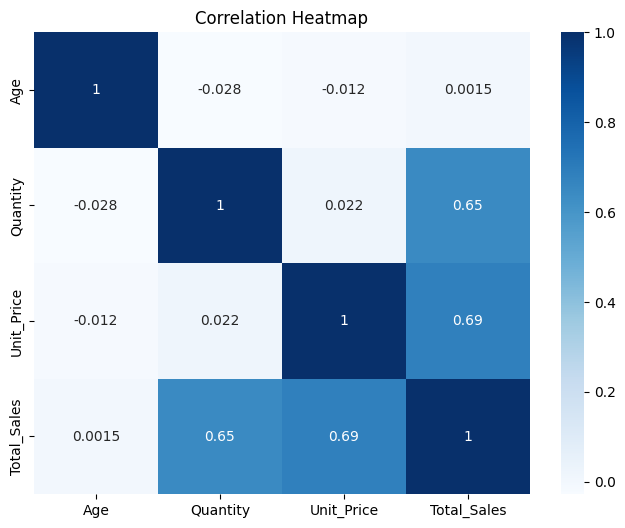

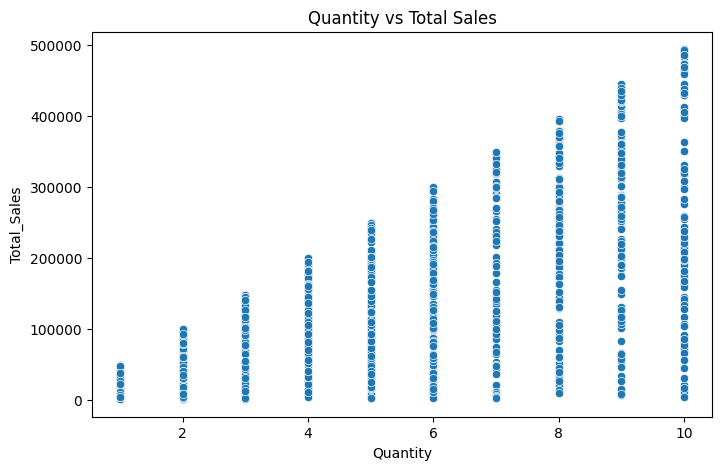

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation
numeric_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Total_Sales"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

# Relationship between Quantity and Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales"
)

plt.title("Quantity vs Total Sales")
plt.show()

In [ ]:
# Dashboard KPIs

dashboard = {
    "Total Sales": df["Total_Sales"].sum(),
    "Total Orders": df["Order_ID"].nunique(),
    "Total Customers": df["Customer_ID"].nunique(),
    "Average Order Value": df["Total_Sales"].mean()
}

print("===== DASHBOARD KPIs =====")

for key, value in dashboard.items():
    print(f"{key}: {value:,.2f}")

print("\n===== TOP PRODUCTS =====")
display(
    product_sales
    .sort_values(ascending=False)
    .head(5)
)

===== DASHBOARD KPIs =====
Total Sales: 139,399,439.65
Total Orders: 992.00
Total Customers: 947.00
Average Order Value: 139,399.44

===== TOP PRODUCTS =====


,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48


In [ ]:
import os

os.makedirs("Task2_Output", exist_ok=True)

df.to_csv(
    "Task2_Output/Task2_EDA_Dataset.csv",
    index=False
)

category_sales.to_csv(
    "Task2_Output/Category_Sales.csv"
)

product_sales.to_csv(
    "Task2_Output/Product_Sales.csv"
)

corr.to_csv(
    "Task2_Output/Correlation_Matrix.csv"
)

print("Task 2 files saved successfully!")

Task 2 files saved successfully!
